# v2 — 04: Modeling
**Iteration 2** model — unified dynasty value predictor including rookies.

**v3 target change:**  = weighted 2-year PPR (0.4 × yr1 + 0.6 × yr2) × age discount.
Age discount = 1 / (1 + 0.04 × max(0, age − 22)) — penalizes older veterans relative to young talent.

**Prerequisite:** Run `v2_03_pipeline_cleaning.ipynb` to build the updated `model_ready` table.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.predictor import (
    load_model_data, train_and_evaluate, get_feature_importance, FEATURE_COLS
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
%matplotlib inline

## 1. Load Model Data

In [2]:
df = load_model_data()
print(f'Shape: {df.shape}')
print(f'Seasons: {sorted(df["season"].unique())}')
if 'is_rookie' in df.columns:
    print(f'Rookies: {int(df["is_rookie"].sum())} | Veterans: {int((df["is_rookie"] == 0).sum())}')
print(f'Positions: {df["position"].value_counts().to_dict()}')

Shape: (4058, 45)
Seasons: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Rookies: 547 | Veterans: 3511
Positions: {'WR': 1546, 'RB': 1144, 'TE': 862, 'QB': 506}


## 2. Feature Availability

In [ ]:
available = [c for c in FEATURE_COLS if c in df.columns]
missing = [c for c in FEATURE_COLS if c not in df.columns]
print(f"{len(available)} of {len(FEATURE_COLS)} features available")
if missing:
    print(f"Missing: {missing}")

# Verify dynasty target
if "dynasty_value" in df.columns:
    print(f"
dynasty_value: mean={df["dynasty_value"].mean():.1f}, min={df["dynasty_value"].min():.1f}, max={df["dynasty_value"].max():.1f}")
    print(f"age_discount:  mean={df["age_discount"].mean():.3f}, min={df["age_discount"].min():.3f}, max={df["age_discount"].max():.3f}")

print("
Null rates by feature:")
for f in available:
    pct = df[f].isna().mean() * 100
    if pct > 0:
        print(f"  {f:35s}: {pct:.1f}% null (handled by imputer)")

## 3. Train & Evaluate All Models

In [4]:
results, pred_df = train_and_evaluate(df)

Train: 3387 | Val: 340 | Test: 331

=== Validation Results ===
  Naive Baseline (prev year)     | MAE:  69.05 | RMSE:  94.00 | R²: -0.077
  Linear Regression              | MAE:  46.49 | RMSE:  60.95 | R²: 0.547
  Ridge Regression               | MAE:  46.49 | RMSE:  60.94 | R²: 0.547
  Random Forest                  | MAE:  47.36 | RMSE:  61.61 | R²: 0.537
  Gradient Boosting              | MAE:  47.76 | RMSE:  62.36 | R²: 0.526
  XGBoost                        | MAE:  47.57 | RMSE:  62.30 | R²: 0.527

Best model on validation: Ridge Regression (MAE=46.49)

=== Test Results (best model) ===
  Ridge Regression               | MAE:  48.16 | RMSE:  63.23 | R²: 0.523


In [ ]:
# Age discount spot-check: same PPR output should score higher for younger players
if "age_discount" in df.columns:
    print("Age discount by age:")
    for age in [22, 24, 26, 28, 30, 32]:
        discount = 1.0 / (1.0 + 0.04 * max(0, age - 22))
        print(f"  Age {age}: {discount:.3f} ({discount*100:.1f}% of full value)")

## 4. Results Comparison

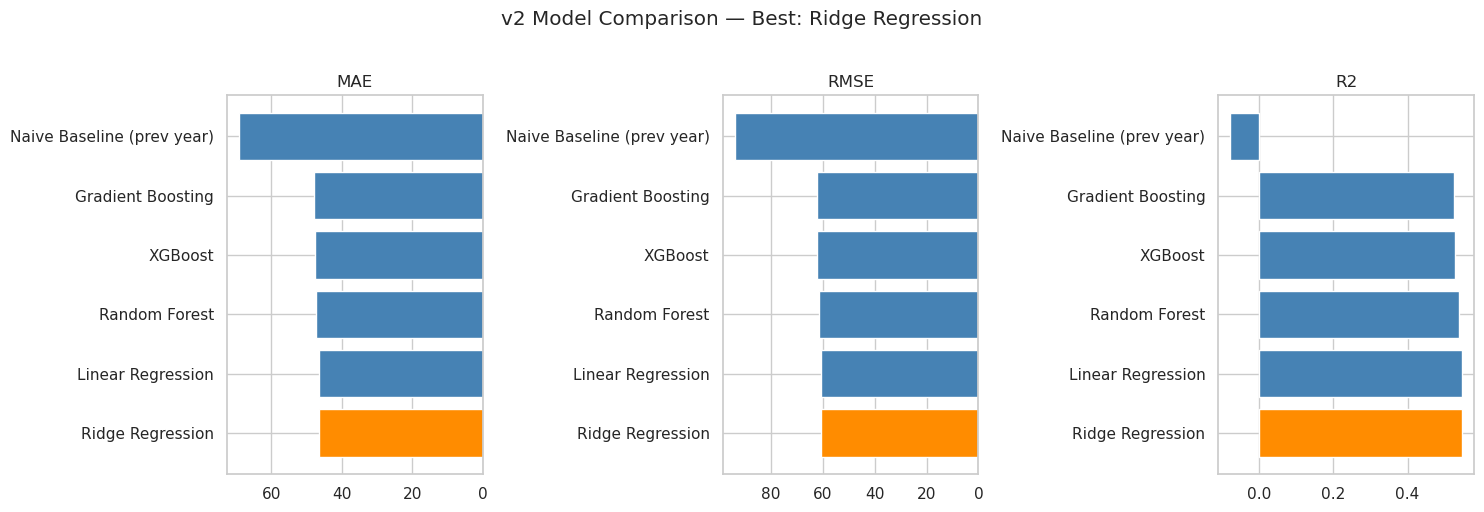

,model,mae,rmse,r2
2,Ridge Regression,46.491374,60.942764,0.547239
1,Linear Regression,46.494071,60.951890,0.547103
3,Random Forest,47.363232,61.606114,0.537329
5,XGBoost,47.567461,62.296122,0.526906
4,Gradient Boosting,47.764952,62.362432,0.525899
0,Naive Baseline (prev year),69.053412,94.000005,-0.077162


In [5]:
results_df = pd.DataFrame(results['results']).sort_values('mae')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['mae', 'rmse', 'r2']):
    colors = ['darkorange' if m == results['best_model'] else 'steelblue'
              for m in results_df['model']]
    ax.barh(results_df['model'], results_df[metric], color=colors)
    ax.set_title(metric.upper())
    if metric in ['mae', 'rmse']:
        ax.invert_xaxis()
plt.suptitle(f'v2 Model Comparison — Best: {results["best_model"]}', y=1.02)
plt.tight_layout()
plt.show()
results_df

## 5. Feature Importance

Train: 3387 | Val: 340 | Test: 331


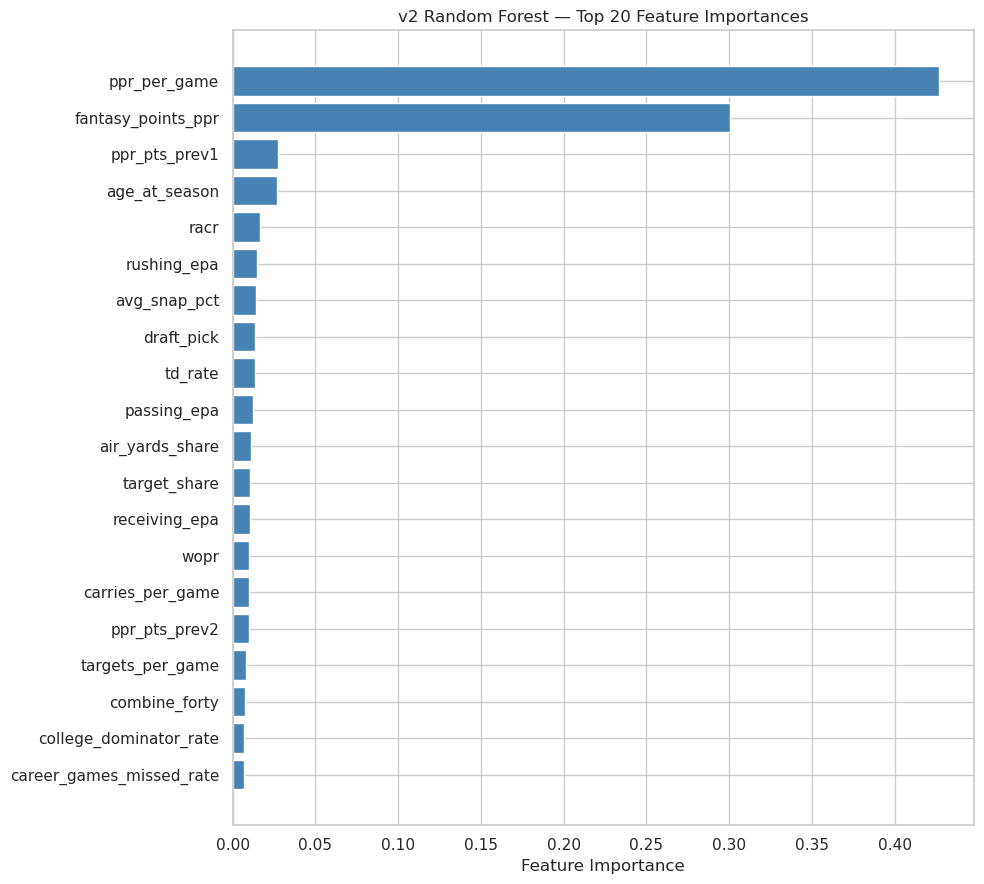


Top 20 features:
                 feature  importance
            ppr_per_game    0.426480
      fantasy_points_ppr    0.300269
           ppr_pts_prev1    0.027544
           age_at_season    0.027080
                    racr    0.016811
             rushing_epa    0.014579
            avg_snap_pct    0.013901
              draft_pick    0.013776
                 td_rate    0.013742
             passing_epa    0.012269
         air_yards_share    0.010846
            target_share    0.010616
           receiving_epa    0.010275
                    wopr    0.009977
        carries_per_game    0.009691
           ppr_pts_prev2    0.009687
        targets_per_game    0.007899
           combine_forty    0.007403
  college_dominator_rate    0.007127
career_games_missed_rate    0.006847


In [6]:
feat_df = get_feature_importance(df)

fig, ax = plt.subplots(figsize=(10, 9))
top = feat_df.head(20)
ax.barh(top['feature'][::-1], top['importance'][::-1], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('v2 Random Forest — Top 20 Feature Importances')
plt.tight_layout()
plt.show()

print('\nTop 20 features:')
print(feat_df.head(20).to_string(index=False))

## 6. Rookie-Specific Analysis
How well does the model predict rookie year output?

In [ ]:
if "is_rookie" in pred_df.columns:
    from sklearn.metrics import mean_absolute_error
    rookies_pred = pred_df[pred_df["is_rookie"] == 1].dropna(subset=["actual_dynasty_value", "predicted_dynasty_value"])
    vets_pred    = pred_df[pred_df["is_rookie"] == 0].dropna(subset=["actual_dynasty_value", "predicted_dynasty_value"])

    if len(rookies_pred) > 0:
        rmae = mean_absolute_error(rookies_pred["actual_dynasty_value"], rookies_pred["predicted_dynasty_value"])
        vmae = mean_absolute_error(vets_pred["actual_dynasty_value"], vets_pred["predicted_dynasty_value"])
        print(f"Rookie MAE: {rmae:.2f} | Veteran MAE: {vmae:.2f}")
        print(f"Rookies in test set: {len(rookies_pred)}")

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        for ax, subset, label in zip(axes, [rookies_pred, vets_pred], ["Rookies", "Veterans"]):
            ax.scatter(subset["actual_dynasty_value"], subset["predicted_dynasty_value"],
                       alpha=0.5, s=30)
            lim = max(subset["actual_dynasty_value"].max(), subset["predicted_dynasty_value"].max()) * 1.05
            ax.plot([0, lim], [0, lim], "r--", alpha=0.5, label="Perfect")
            ax.set_title(f"{label} — Actual vs Predicted Dynasty Value")
            ax.set_xlabel("Actual Dynasty Value")
            ax.set_ylabel("Predicted Dynasty Value")
            ax.legend()
        plt.tight_layout()
        plt.show()

## 7. Dynasty Rankings Output (2024 prediction)

In [ ]:
display_cols = ["predicted_rank", "full_name", "position", "predicted_dynasty_value",
                "actual_dynasty_value", "error"]
if "is_rookie" in pred_df.columns:
    display_cols.insert(3, "is_rookie")
available_display = [c for c in display_cols if c in pred_df.columns]

print("=== Top 30 Overall Dynasty Rankings ===")
pred_df[available_display].head(30)

In [ ]:
# Top rookies specifically
if "is_rookie" in pred_df.columns:
    rookie_rankings = pred_df[pred_df["is_rookie"] == 1].head(15)
    print("=== Top 15 Rookie Dynasty Rankings ===")
    print(rookie_rankings[available_display].to_string(index=False))